**Name** Mariam Riaz

# Airbnb NYC Data Analysis

The dataset used in this notebook contains Airbnb listings in New York City.  

- **Direct CSV from GitHub:** [AB_NYC_2019.csv](https://github.com/Mariz133/Airbnb_NYC_Project/blob/main/AB_NYC_2019.csv)  
- **Original dataset on Kaggle:** [New York City Airbnb Open Data](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data?resource=download)  

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor

In [70]:
airbnb_NYC = pd.read_csv('AB_NYC_2019.csv')
airbnb_NYC

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [71]:
airbnb_NYC.shape

(48895, 16)

In [72]:
airbnb_NYC.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,int64


In [73]:
airbnb_NYC['last_review'] = pd.to_datetime(airbnb_NYC['last_review'])
airbnb_NYC.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,int64


In [74]:
print(airbnb_NYC['last_review'].min())
print(airbnb_NYC['last_review'].max())


2011-03-28 00:00:00
2019-07-08 00:00:00


In [75]:
airbnb_NYC.describe(include='all')

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,48879,4.889500e+04,48874,48895,48895,48895.000000,48895.000000,48895,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
unique,NaN,47905,NaN,11452,5,221,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Hillside Hotel,NaN,Michael,Manhattan,Williamsburg,NaN,NaN,Entire home/apt,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,18,NaN,417,21661,3920,NaN,NaN,25409,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.901714e+07,NaN,6.762001e+07,NaN,NaN,NaN,40.728949,-73.952170,NaN,152.720687,7.029962,23.274466,2018-10-04 01:47:23.910099456,1.373221,7.143982,112.781327
min,2.539000e+03,NaN,2.438000e+03,NaN,NaN,NaN,40.499790,-74.244420,NaN,0.000000,1.000000,0.000000,2011-03-28 00:00:00,0.010000,1.000000,0.000000
25%,9.471945e+06,NaN,7.822033e+06,NaN,NaN,NaN,40.690100,-73.983070,NaN,69.000000,1.000000,1.000000,2018-07-08 00:00:00,0.190000,1.000000,0.000000
50%,1.967728e+07,NaN,3.079382e+07,NaN,NaN,NaN,40.723070,-73.955680,NaN,106.000000,3.000000,5.000000,2019-05-19 00:00:00,0.720000,1.000000,45.000000
75%,2.915218e+07,NaN,1.074344e+08,NaN,NaN,NaN,40.763115,-73.936275,NaN,175.000000,5.000000,24.000000,2019-06-23 00:00:00,2.020000,2.000000,227.000000
max,3.648724e+07,NaN,2.743213e+08,NaN,NaN,NaN,40.913060,-73.712990,NaN,10000.000000,1250.000000,629.000000,2019-07-08 00:00:00,58.500000,327.000000,365.000000


In [76]:
display(airbnb_NYC[airbnb_NYC['minimum_nights']  > 365] [['name', 'host_name', 'neighbourhood_group', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'availability_365']])

,name,host_name,neighbourhood_group,room_type,price,minimum_nights,number_of_reviews,availability_365
1305,800sqft apartment with huge terrace,Alessandra,Brooklyn,Entire home/apt,115,370,6,365
2854,NaN,Peter,Manhattan,Entire home/apt,400,1000,0,362
5767,Prime W. Village location 1 bdrm,Genevieve,Manhattan,Entire home/apt,180,1250,2,365
7355,Beautiful Fully Furnished 1 bed/bth,Aliya,Queens,Entire home/apt,134,500,30,90
8014,Wonderful Large 1 bedroom,John,Manhattan,Entire home/apt,75,500,0,362
10829,Brand New Luxury Apt Lease Takeover,Shining,Queens,Entire home/apt,199,480,0,365
11193,Zen Room in Crown Heights Brooklyn,Laura,Brooklyn,Private room,50,500,10,365
13404,Historic Designer 2 Bed. Apartment,Glenn H.,Manhattan,Entire home/apt,99,999,2,42
14285,Peaceful apartment close to F/G,Amanda,Brooklyn,Private room,45,500,0,358
15946,"Bright Luxury Studio, Central Loc.",Sarah,Manhattan,Entire home/apt,250,366,0,365


In [77]:
print("Listings with a price of $0:")
#display(df[df['price'] == 0][['name', 'host_name', 'neighbourhood_group', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'availability_365']])
display(airbnb_NYC[airbnb_NYC['price'] == 0] [['name', 'host_name', 'neighbourhood_group', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'availability_365']])

Listings with a price of $0:


,name,host_name,neighbourhood_group,room_type,price,minimum_nights,number_of_reviews,availability_365
23161,"Huge Brooklyn Brownstone Living, Close to it all.",Kimberly,Brooklyn,Private room,0,4,1,28
25433,★Hostel Style Room | Ideal Traveling Buddies★,Anisha,Bronx,Private room,0,2,55,127
25634,"MARTIAL LOFT 3: REDEMPTION (upstairs, 2nd room)",Martial Loft,Brooklyn,Private room,0,2,16,0
25753,"Sunny, Quiet Room in Greenpoint",Lauren,Brooklyn,Private room,0,2,12,0
25778,Modern apartment in the heart of Williamsburg,Aymeric,Brooklyn,Entire home/apt,0,5,3,73
25794,Spacious comfortable master bedroom with nice ...,Adeyemi,Brooklyn,Private room,0,1,93,176
25795,Contemporary bedroom in brownstone with nice view,Adeyemi,Brooklyn,Private room,0,1,95,232
25796,Cozy yet spacious private brownstone bedroom,Adeyemi,Brooklyn,Private room,0,1,95,222
26259,the best you can find,Qiuchi,Manhattan,Entire home/apt,0,3,0,0
26841,Coliving in Brooklyn! Modern design / Shared room,Sergii,Brooklyn,Shared room,0,30,2,333


In [78]:
print("Listings with a price of less than $10:")
display(airbnb_NYC[airbnb_NYC['price'] == 10][['name', 'host_name', 'neighbourhood_group', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'availability_365']])

Listings with a price of less than $10:


,name,host_name,neighbourhood_group,room_type,price,minimum_nights,number_of_reviews,availability_365
2860,Large furnished 2 bedrooms- - 30 days Minimum,Sally,Manhattan,Entire home/apt,10,30,0,137
21700,Couch in Harlem Harvey Refugees only,Morgan,Manhattan,Shared room,10,1,0,0
22261,"Newly renovated, fully furnished room in Brooklyn",Katie,Brooklyn,Private room,10,5,0,0
22287,Jen Apt,Jennifer,Manhattan,Private room,10,5,2,0
22835,IT'S SIMPLY CONVENIENT!,Maria,Queens,Entire home/apt,10,1,43,252
23256,"Quiet, Cozy UES Studio Near the Subway",Amy,Manhattan,Entire home/apt,10,3,10,0
24100,"Girls only, cozy room one block from Times Square",Mario,Manhattan,Shared room,10,1,2,0
27972,Spacious 2-bedroom Apt in Heart of Greenpoint,Vishanti & Jeremy,Brooklyn,Entire home/apt,10,1,93,32
31066,"Very Spacious bedroom, steps from CENTRAL PARK.",Salim,Manhattan,Private room,10,1,2,0
31407,Cozy feel at home studio,Maureen,Manhattan,Private room,10,5,42,2


In [79]:
print("Listings with a price of $10,000:")
#display(df[df['price'] == 10000][['name', 'host_name', 'neighbourhood_group', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'availability_365']])
display(airbnb_NYC[airbnb_NYC['price'] == 10000] [['name', 'host_name', 'neighbourhood_group', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'availability_365']])

Listings with a price of $10,000:


,name,host_name,neighbourhood_group,room_type,price,minimum_nights,number_of_reviews,availability_365
9151,Furnished room in Astoria apartment,Kathrine,Queens,Private room,10000,100,2,0
17692,Luxury 1 bedroom apt. -stunning Manhattan views,Erin,Brooklyn,Entire home/apt,10000,5,5,0
29238,1-BR Lincoln Center,Jelena,Manhattan,Entire home/apt,10000,30,0,83


In [80]:
# Remove rows where price is 0
#price is 0, which is illogical for a listing
airbnb_NYC = airbnb_NYC[airbnb_NYC['price'] > 0]
airbnb_NYC.shape


(48884, 16)

In [81]:
#Remove extreme minimum_nights outliers
airbnb_NYC = airbnb_NYC[airbnb_NYC['minimum_nights'] <= 365]
airbnb_NYC.shape

(48870, 16)

In [82]:
airbnb_NYC.isnull().sum()

,0
id,0
name,15
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [83]:
airbnb_NYC['name'].fillna('Unknown', inplace=True)
airbnb_NYC['host_name'].fillna('Unknown', inplace=True)

/tmp/ipykernel_3459/1499402464.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  airbnb_NYC['name'].fillna('Unknown', inplace=True)
/tmp/ipykernel_3459/1499402464.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [84]:
airbnb_NYC['last_review'].fillna('No reviews', inplace=True)
airbnb_NYC['reviews_per_month'].fillna(0, inplace=True)

/tmp/ipykernel_3459/3954592106.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  airbnb_NYC['last_review'].fillna('No reviews', inplace=True)
/tmp/ipykernel_3459/3954592106.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'No reviews' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  airbnb_NYC['last_review'].fillna('No reviews', inplace=True)
/tmp/ipykernel_3459/3954592106.py:2: FutureWarning:

In [85]:
airbnb_NYC.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [86]:
airbnb_NYC.duplicated().sum()

np.int64(0)

In [87]:
airbnb_NYC['room_type'].value_counts()

,count
room_type,
Entire home/apt,25398
Private room,22315
Shared room,1157


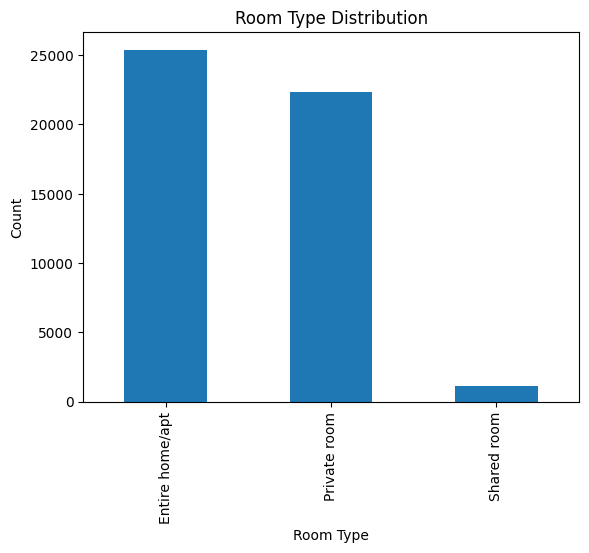

In [88]:
airbnb_NYC['room_type'].value_counts().plot(kind='bar')
plt.title('Room Type Distribution')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.savefig('room_type_distribution.png')
plt.show()

In [89]:
airbnb_NYC['neighbourhood_group'].value_counts()

,count
neighbourhood_group,
Manhattan,21654
Brooklyn,20089
Queens,5664
Bronx,1090
Staten Island,373


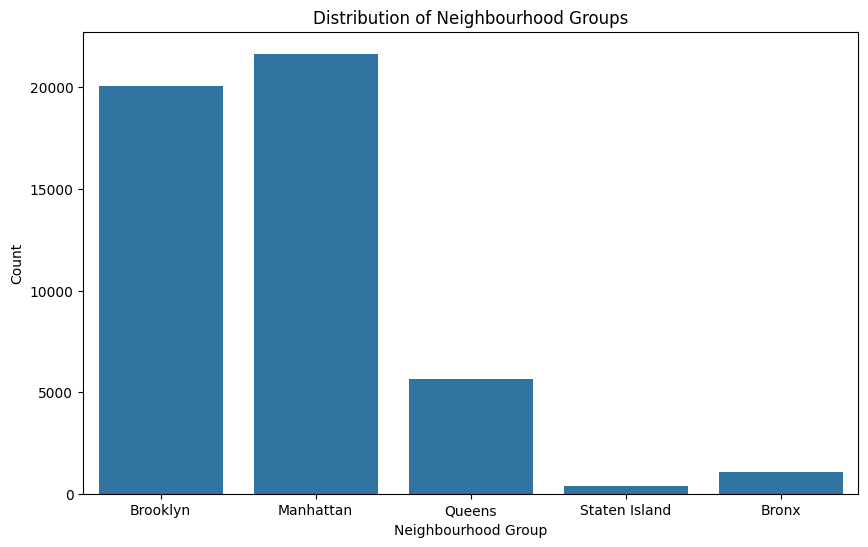

In [90]:
plt.figure(figsize=(10, 6))
sns.countplot(data=airbnb_NYC, x='neighbourhood_group')
plt.title('Distribution of Neighbourhood Groups')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Count')
plt.savefig('neighbourhood_group_distribution.png')
plt.show()

In [91]:
airbnb_NYC['price'].value_counts()

,count
price,
100,2051
150,2047
50,1532
60,1458
200,1401
...,...
580,1
659,1
381,1


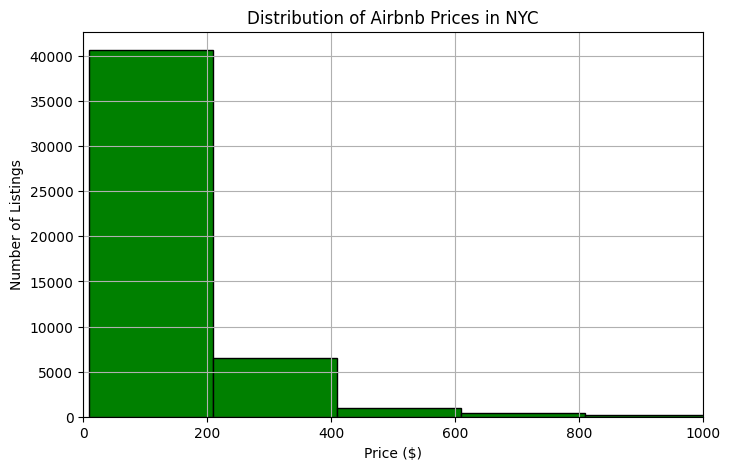

In [92]:
plt.figure(figsize=(8,5))
airbnb_NYC['price'].hist(bins=50, color='green', edgecolor='black')
plt.title("Distribution of Airbnb Prices in NYC")
plt.xlabel("Price ($)")
plt.ylabel('Number of Listings')
plt.xlim(0, 1000)  # limit extreme outliers for clarity
plt.savefig('price_distribution.png')
plt.show()

In [93]:
airbnb_NYC['number_of_reviews'].value_counts()

,count
number_of_reviews,
0,10043
1,5243
2,3462
3,2519
4,1994
...,...
372,1
299,1
436,1


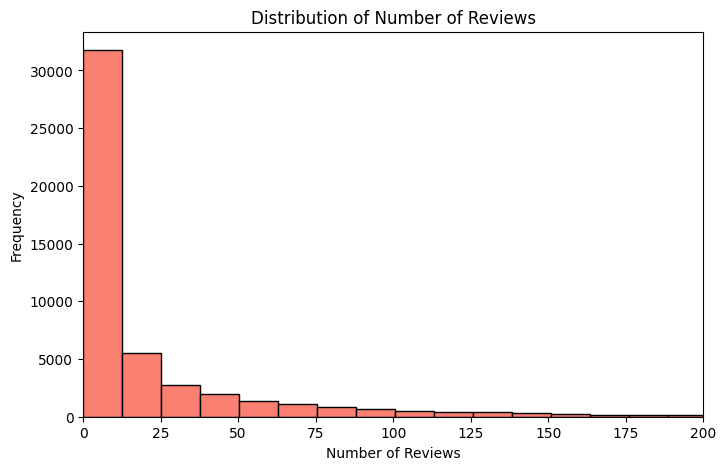

In [94]:
plt.figure(figsize=(8,5))
plt.hist(airbnb_NYC['number_of_reviews'], bins=50, color='salmon', edgecolor='black')
plt.title("Distribution of Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Frequency")
plt.xlim(0, 200)  # limit extreme outliers
plt.savefig('number_of_reviews_distribution.png')
plt.show()

In [95]:
airbnb_NYC['availability_365'].value_counts()

,count
availability_365,
0,17530
365,1289
364,491
1,408
89,361
...,...
195,26
183,24
196,24


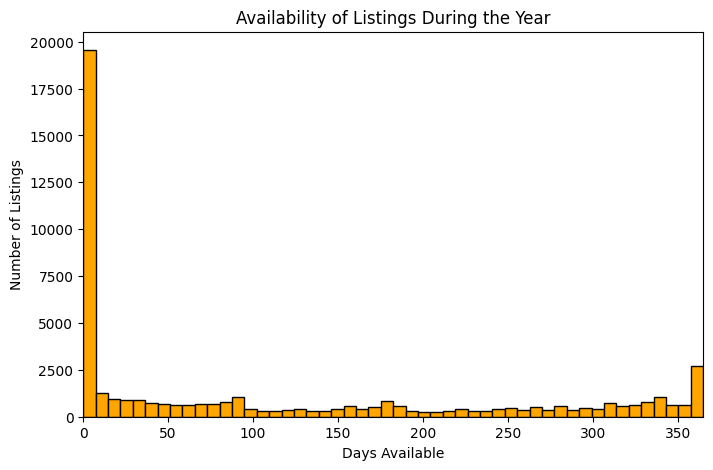

In [96]:
plt.figure(figsize=(8,5))
plt.hist(airbnb_NYC['availability_365'], bins=50, color='orange', edgecolor='black')
plt.title("Availability of Listings During the Year")
plt.xlabel("Days Available")
plt.ylabel("Number of Listings")
plt.xlim(0, 365)  # limit extreme outliers
plt.savefig('availability_distribution.png')
plt.show()

In [97]:
airbnb_NYC['minimum_nights'].value_counts().sort_index()

,count
minimum_nights,
1,12717
2,11693
3,7998
4,3302
5,3033
...,...
300,6
354,1
360,5


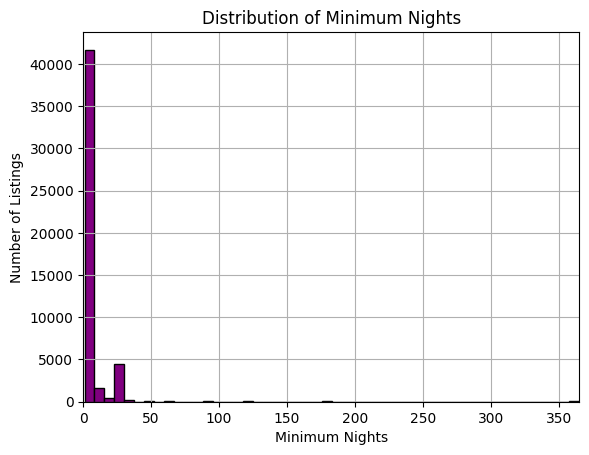

In [98]:
airbnb_NYC['minimum_nights'].hist(bins=50, color='purple', edgecolor='black')
plt.title("Distribution of Minimum Nights")
plt.xlabel("Minimum Nights")
plt.ylabel("Number of Listings")
plt.xlim(0, 365)  # limit extreme outliers
plt.savefig('minimum_nights_distribution.png')
plt.show()

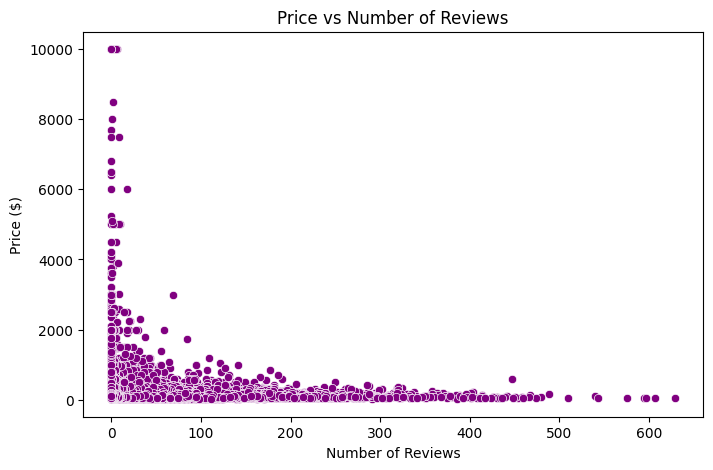

In [99]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=airbnb_NYC, x='number_of_reviews', y='price', color='purple')
plt.title("Price vs Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Price ($)")
plt.savefig('price_vs_reviews.png')
plt.show()

<Figure size 800x500 with 0 Axes>

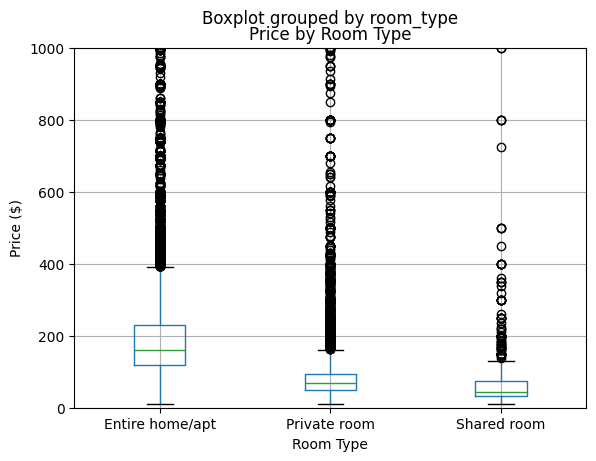

In [100]:
plt.figure(figsize=(8,5))
airbnb_NYC.boxplot(column='price', by='room_type')
plt.title("Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price ($)")
plt.ylim(0, 1000)  # ignore extreme outliers
plt.savefig('price_by_room_type.png')
plt.show()

In [101]:
# obtain a dataframe of average price across five boroughs in room_type
pd.DataFrame(airbnb_NYC.groupby(['neighbourhood_group','room_type'])['price'].mean())

price
neighbourhood_group room_type                  
Bronx               Entire home/apt  127.506596
                    Private room      66.890937
                    Shared room       59.800000
Brooklyn            Entire home/apt  178.356844
                    Private room      76.553547
                    Shared room       50.773723
Manhattan           Entire home/apt  249.276359
                    Private room     116.776622
                    Shared room       88.933194
Queens              Entire home/apt  147.031996
                    Private room      71.762456
                    Shared room       69.020202
Staten Island       Entire home/apt  173.846591
                    Private room      62.292553
                    Shared room       57.444444

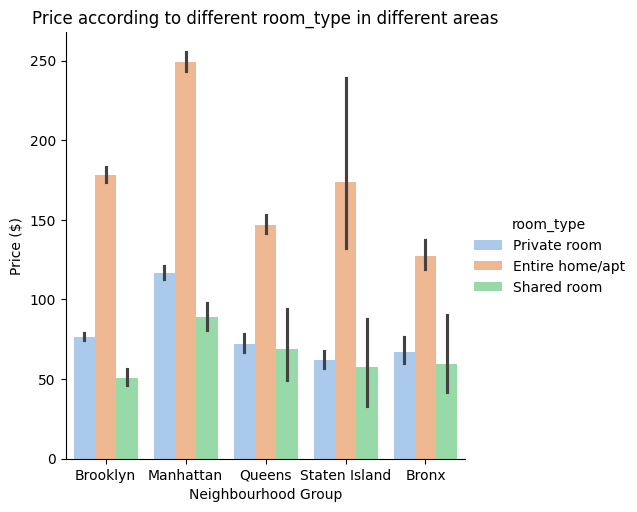

In [102]:
# Price according to different room_type in different areas
sns.catplot(x='neighbourhood_group',y='price',data=airbnb_NYC,kind='bar',hue='room_type',palette='pastel')
plt.title("Price according to different room_type in different areas")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Price ($)")
plt.savefig('price_according_to_room_type.png')
plt.show()

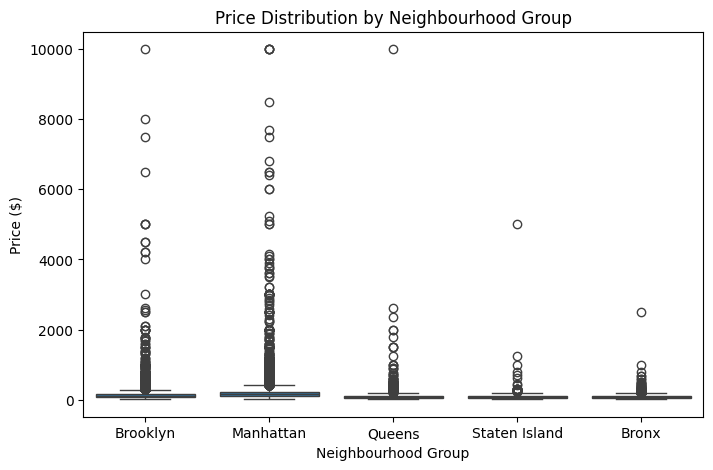

In [103]:
plt.figure(figsize=(8,5))
sns.boxplot(x='neighbourhood_group', y='price', data=airbnb_NYC)
plt.title("Price Distribution by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Price ($)")
plt.savefig('price_by_neighbourhood_group.png')
plt.show()

In [104]:
listings_under_30 = airbnb_NYC[airbnb_NYC['price'] <= 30]
print(f"Total number of listings under $30: {len(listings_under_30)}")


Total number of listings under $30: 648


In [105]:
entire_apt_under_100 = airbnb_NYC[(airbnb_NYC['room_type'] == 'Entire home/apt') & (airbnb_NYC['price'] <= 100)]
print(f"Total number of entire apartment listings under $100: {len(entire_apt_under_100)}")


Total number of entire apartment listings under $100: 4570


#Milestone 2

In [106]:
airbnb_model = pd.get_dummies(
    airbnb_NYC,
    columns=['room_type','neighbourhood_group'],
    drop_first=True
)
# Rename columns to replace spaces with underscores for compatibility with statsmodels formulas
airbnb_model.columns = airbnb_model.columns.str.replace(' ', '_')

In [107]:
airbnb_model.head()

,id,name,host_id,host_name,neighbourhood,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,room_type_Private_room,room_type_Shared_room,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten_Island
0,2539,Clean & quiet apt home by the park,2787,John,Kensington,40.64749,-73.97237,149,1,9,2018-10-19 00:00:00,0.21,6,365,True,False,True,False,False,False
1,2595,Skylit Midtown Castle,2845,Jennifer,Midtown,40.75362,-73.98377,225,1,45,2019-05-21 00:00:00,0.38,2,355,False,False,False,True,False,False
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Harlem,40.80902,-73.94190,150,3,0,No reviews,0.00,1,365,True,False,False,True,False,False
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Clinton Hill,40.68514,-73.95976,89,1,270,2019-07-05 00:00:00,4.64,1,194,False,False,True,False,False,False
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,East Harlem,40.79851,-73.94399,80,10,9,2018-11-19 00:00:00,0.10,1,0,False,False,False,True,False,False


In [108]:
lm1= smf.ols('price ~ latitude + longitude + number_of_reviews + reviews_per_month + availability_365 + calculated_host_listings_count + room_type_Private_room + room_type_Shared_room+ neighbourhood_group_Brooklyn + neighbourhood_group_Staten_Island + neighbourhood_group_Manhattan + neighbourhood_group_Queens' , data=airbnb_model).fit()
lm1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.098
Model:                            OLS   Adj. R-squared:                  0.098
Method:                 Least Squares   F-statistic:                     444.3
Date:                Tue, 28 Apr 2026   Prob (F-statistic):               0.00
Time:                        01:54:31   Log-Likelihood:            -3.3469e+05
No. Observations:               48870   AIC:                         6.694e+05
Df Residuals:                   48857   BIC:                         6.695e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
=============================================================================================================
                                                coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                 -2.768e+04   3219.766     -8.598      0.000    -3.4e+04   -2.14e+04
room_type_Private_room[T.True]             -105.9836      2.158    -49.106      0.000    -110.214    -101.753
room_type_Shared_room[T.True]              -142.0717      6.890    -20.620      0.000    -155.576    -128.567
neighbourhood_group_Brooklyn[T.True]        -33.9950      8.780     -3.872      0.000     -51.204     -16.786
neighbourhood_group_Staten_Island[T.True]  -151.2616     16.705     -9.055      0.000    -184.003    -118.520
neighbourhood_group_Manhattan[T.True]        28.2095      7.957      3.545      0.000      12.614      43.805
neighbourhood_group_Queens[T.True]           -4.6990      8.450     -0.556      0.578     -21.261      11.863
latitude                                   -210.3487     31.403     -6.698      0.000    -271.899    -148.799
longitude                                  -492.8523     36.146    -13.635      0.000    -563.700    -422.005
number_of_reviews                            -0.2430      0.029     -8.386      0.000      -0.300      -0.186
reviews_per_month                            -2.9565      0.811     -3.644      0.000      -4.547      -1.366
availability_365                              0.1953      0.008     23.360      0.000       0.179       0.212
calculated_host_listings_count               -0.1768      0.033     -5.337      0.000      -0.242      -0.112
==============================================================================
Omnibus:                   110304.207   Durbin-Watson:                   1.848
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        992278737.059
Skew:                          21.438   Prob(JB):                         0.00
Kurtosis:                     699.756   Cond. No.                     5.76e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.76e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [109]:
lm2= smf.ols('price ~ latitude + longitude + number_of_reviews + reviews_per_month + availability_365 + calculated_host_listings_count + room_type_Private_room + room_type_Shared_room + neighbourhood_group_Brooklyn + neighbourhood_group_Staten_Island + neighbourhood_group_Manhattan', data=airbnb_model).fit()
lm2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.098
Model:                            OLS   Adj. R-squared:                  0.098
Method:                 Least Squares   F-statistic:                     484.7
Date:                Tue, 28 Apr 2026   Prob (F-statistic):               0.00
Time:                        01:54:31   Log-Likelihood:            -3.3469e+05
No. Observations:               48870   AIC:                         6.694e+05
Df Residuals:                   48858   BIC:                         6.695e+05
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
=============================================================================================================
                                                coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                 -2.823e+04   3064.651     -9.213      0.000   -3.42e+04   -2.22e+04
room_type_Private_room[T.True]             -106.0180      2.157    -49.142      0.000    -110.246    -101.790
room_type_Shared_room[T.True]              -142.0078      6.889    -20.613      0.000    -155.510    -128.505
neighbourhood_group_Brooklyn[T.True]        -29.7652      4.385     -6.787      0.000     -38.361     -21.170
neighbourhood_group_Staten_Island[T.True]  -146.9546     14.801     -9.929      0.000    -175.964    -117.945
neighbourhood_group_Manhattan[T.True]        31.7318      4.816      6.589      0.000      22.292      41.171
latitude                                   -202.5523     28.099     -7.208      0.000    -257.627    -147.478
longitude                                  -495.9295     35.720    -13.884      0.000    -565.941    -425.918
number_of_reviews                            -0.2434      0.029     -8.399      0.000      -0.300      -0.187
reviews_per_month                            -2.9468      0.811     -3.633      0.000      -4.537      -1.357
availability_365                              0.1956      0.008     23.434      0.000       0.179       0.212
calculated_host_listings_count               -0.1765      0.033     -5.328      0.000      -0.241      -0.112
==============================================================================
Omnibus:                   110303.472   Durbin-Watson:                   1.848
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        992202828.611
Skew:                          21.438   Prob(JB):                         0.00
Kurtosis:                     699.729   Cond. No.                     5.49e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.49e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [110]:
#the performance is very poor Airbnb prices are heavily skewed and have extreme outliers
# Remove extreme price outliers
airbnb_NYC = airbnb_NYC[airbnb_NYC['price'] <= 1000]

In [111]:
airbnb_model = pd.get_dummies(
    airbnb_NYC,
    columns=['room_type','neighbourhood_group'],
    drop_first=True
)
# Rename columns to replace spaces with underscores for compatibility with statsmodels formulas
airbnb_model.columns = airbnb_model.columns.str.replace(' ', '_')

In [112]:
lm3 = smf.ols(
'price ~ latitude + longitude + minimum_nights + number_of_reviews + availability_365 + room_type_Private_room + room_type_Shared_room + neighbourhood_group_Brooklyn + neighbourhood_group_Manhattan + neighbourhood_group_Staten_Island',
data=airbnb_model
).fit()

lm3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.313
Model:                            OLS   Adj. R-squared:                  0.313
Method:                 Least Squares   F-statistic:                     2214.
Date:                Tue, 28 Apr 2026   Prob (F-statistic):               0.00
Time:                        01:54:31   Log-Likelihood:            -2.9136e+05
No. Observations:               48631   AIC:                         5.827e+05
Df Residuals:                   48620   BIC:                         5.828e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
=============================================================================================================
                                                coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                 -2.387e+04   1296.391    -18.415      0.000   -2.64e+04   -2.13e+04
room_type_Private_room[T.True]              -97.6011      0.917   -106.412      0.000     -99.399     -95.803
room_type_Shared_room[T.True]              -126.9170      2.925    -43.387      0.000    -132.650    -121.183
neighbourhood_group_Brooklyn[T.True]        -19.9030      1.857    -10.719      0.000     -23.542     -16.264
neighbourhood_group_Manhattan[T.True]        29.2344      2.046     14.289      0.000      25.224      33.244
neighbourhood_group_Staten_Island[T.True]  -124.6328      6.276    -19.860      0.000    -136.933    -112.332
latitude                                   -140.2225     11.895    -11.788      0.000    -163.537    -116.908
longitude                                  -402.4505     15.092    -26.666      0.000    -432.032    -372.869
minimum_nights                               -0.5419      0.028    -19.305      0.000      -0.597      -0.487
number_of_reviews                            -0.1920      0.010    -19.041      0.000      -0.212      -0.172
availability_365                              0.1432      0.004     40.829      0.000       0.136       0.150
==============================================================================
Omnibus:                    37366.447   Durbin-Watson:                   1.870
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           894369.373
Skew:                           3.552   Prob(JB):                         0.00
Kurtosis:                      22.771   Cond. No.                     5.44e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.44e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Calculate MSE Using sklearn
###using best model variables

In [113]:
x = airbnb_model[
['latitude',
 'longitude',
 'number_of_reviews',
 'minimum_nights',
 'availability_365',
 'room_type_Private_room',
 'room_type_Shared_room',
 'neighbourhood_group_Brooklyn',
 'neighbourhood_group_Staten_Island',
 'neighbourhood_group_Manhattan']
]

y = airbnb_model['price']

In [114]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [115]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [116]:
y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)

In [117]:
mean_squared_error(y_test, y_pred_test)

8433.209449335418

In [118]:
mean_squared_error(y_train, y_pred_train)

9596.23344562928

#Model 2

In [119]:
tree1 = DecisionTreeRegressor(max_depth=3)
tree1.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=3)

In [120]:
y_pred_train1 = tree1.predict(x_train)
y_pred_test1 = tree1.predict(x_test)

In [121]:
mse_train1 = mean_squared_error(y_train, y_pred_train1)
mse_train1


9875.777009271173

In [122]:
mse_test1 = mean_squared_error(y_test, y_pred_test1)
mse_test1

8663.833404136834

In [123]:
tree2 = DecisionTreeRegressor(max_depth=5)
tree2.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=5)

In [124]:
y_pred_train2 = tree2.predict(x_train)
y_pred_test2 = tree2.predict(x_test)

In [125]:
mse_train2 = mean_squared_error(y_train, y_pred_train2)
mse_train2

9120.110009135075

In [126]:
mse_test2 = mean_squared_error(y_test, y_pred_test2)
mse_test2

8059.986165910932

In [127]:
tree3 = DecisionTreeRegressor(max_depth=7)
tree3.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=7)

In [128]:
y_pred_train3 = tree3.predict(x_train)
y_pred_test3 = tree3.predict(x_test)

In [129]:
mse_train3 = mean_squared_error(y_train, y_pred_train3)
mse_train3

8246.003306912593

In [130]:
mse_test3 = mean_squared_error(y_test, y_pred_test3)
mse_test3

7760.879957312717

In [131]:
tree4 = DecisionTreeRegressor(max_depth=9)

tree4.fit(x_train, y_train)

y_pred_train4 = tree4.predict(x_train)
y_pred_test4 = tree4.predict(x_test)

mse_train4 = mean_squared_error(y_train, y_pred_train4)
mse_test4 = mean_squared_error(y_test, y_pred_test4)

mse_train4, mse_test4

(7345.875261433964, 7910.659724125263)

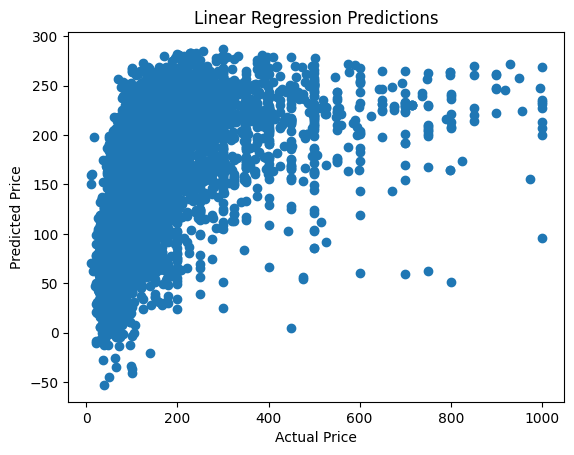

In [132]:
plt.scatter(y_test, y_pred_test)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression Predictions")
plt.show()

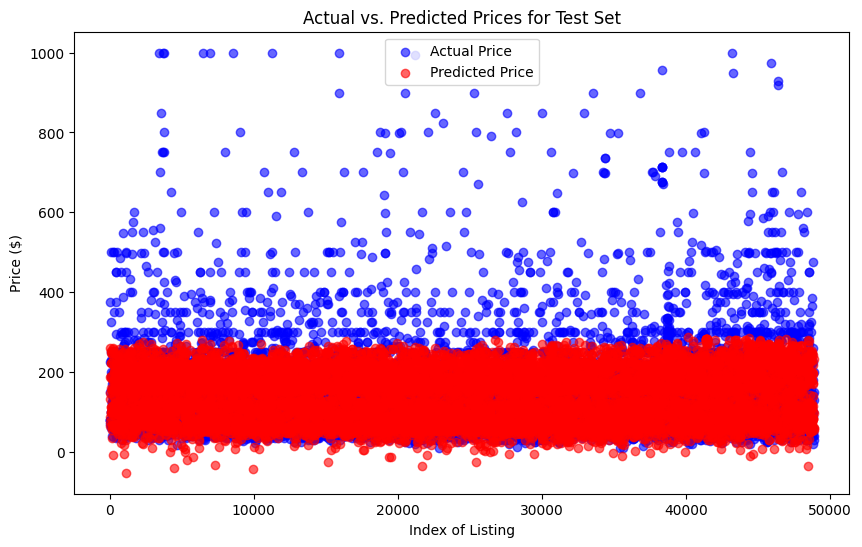

In [133]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test.index, y_test, color='blue', label='Actual Price', alpha=0.6)
plt.scatter(y_test.index, y_pred_test, color='red', label='Predicted Price', alpha=0.6)
plt.title('Actual vs. Predicted Prices for Test Set')
plt.xlabel('Index of Listing')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

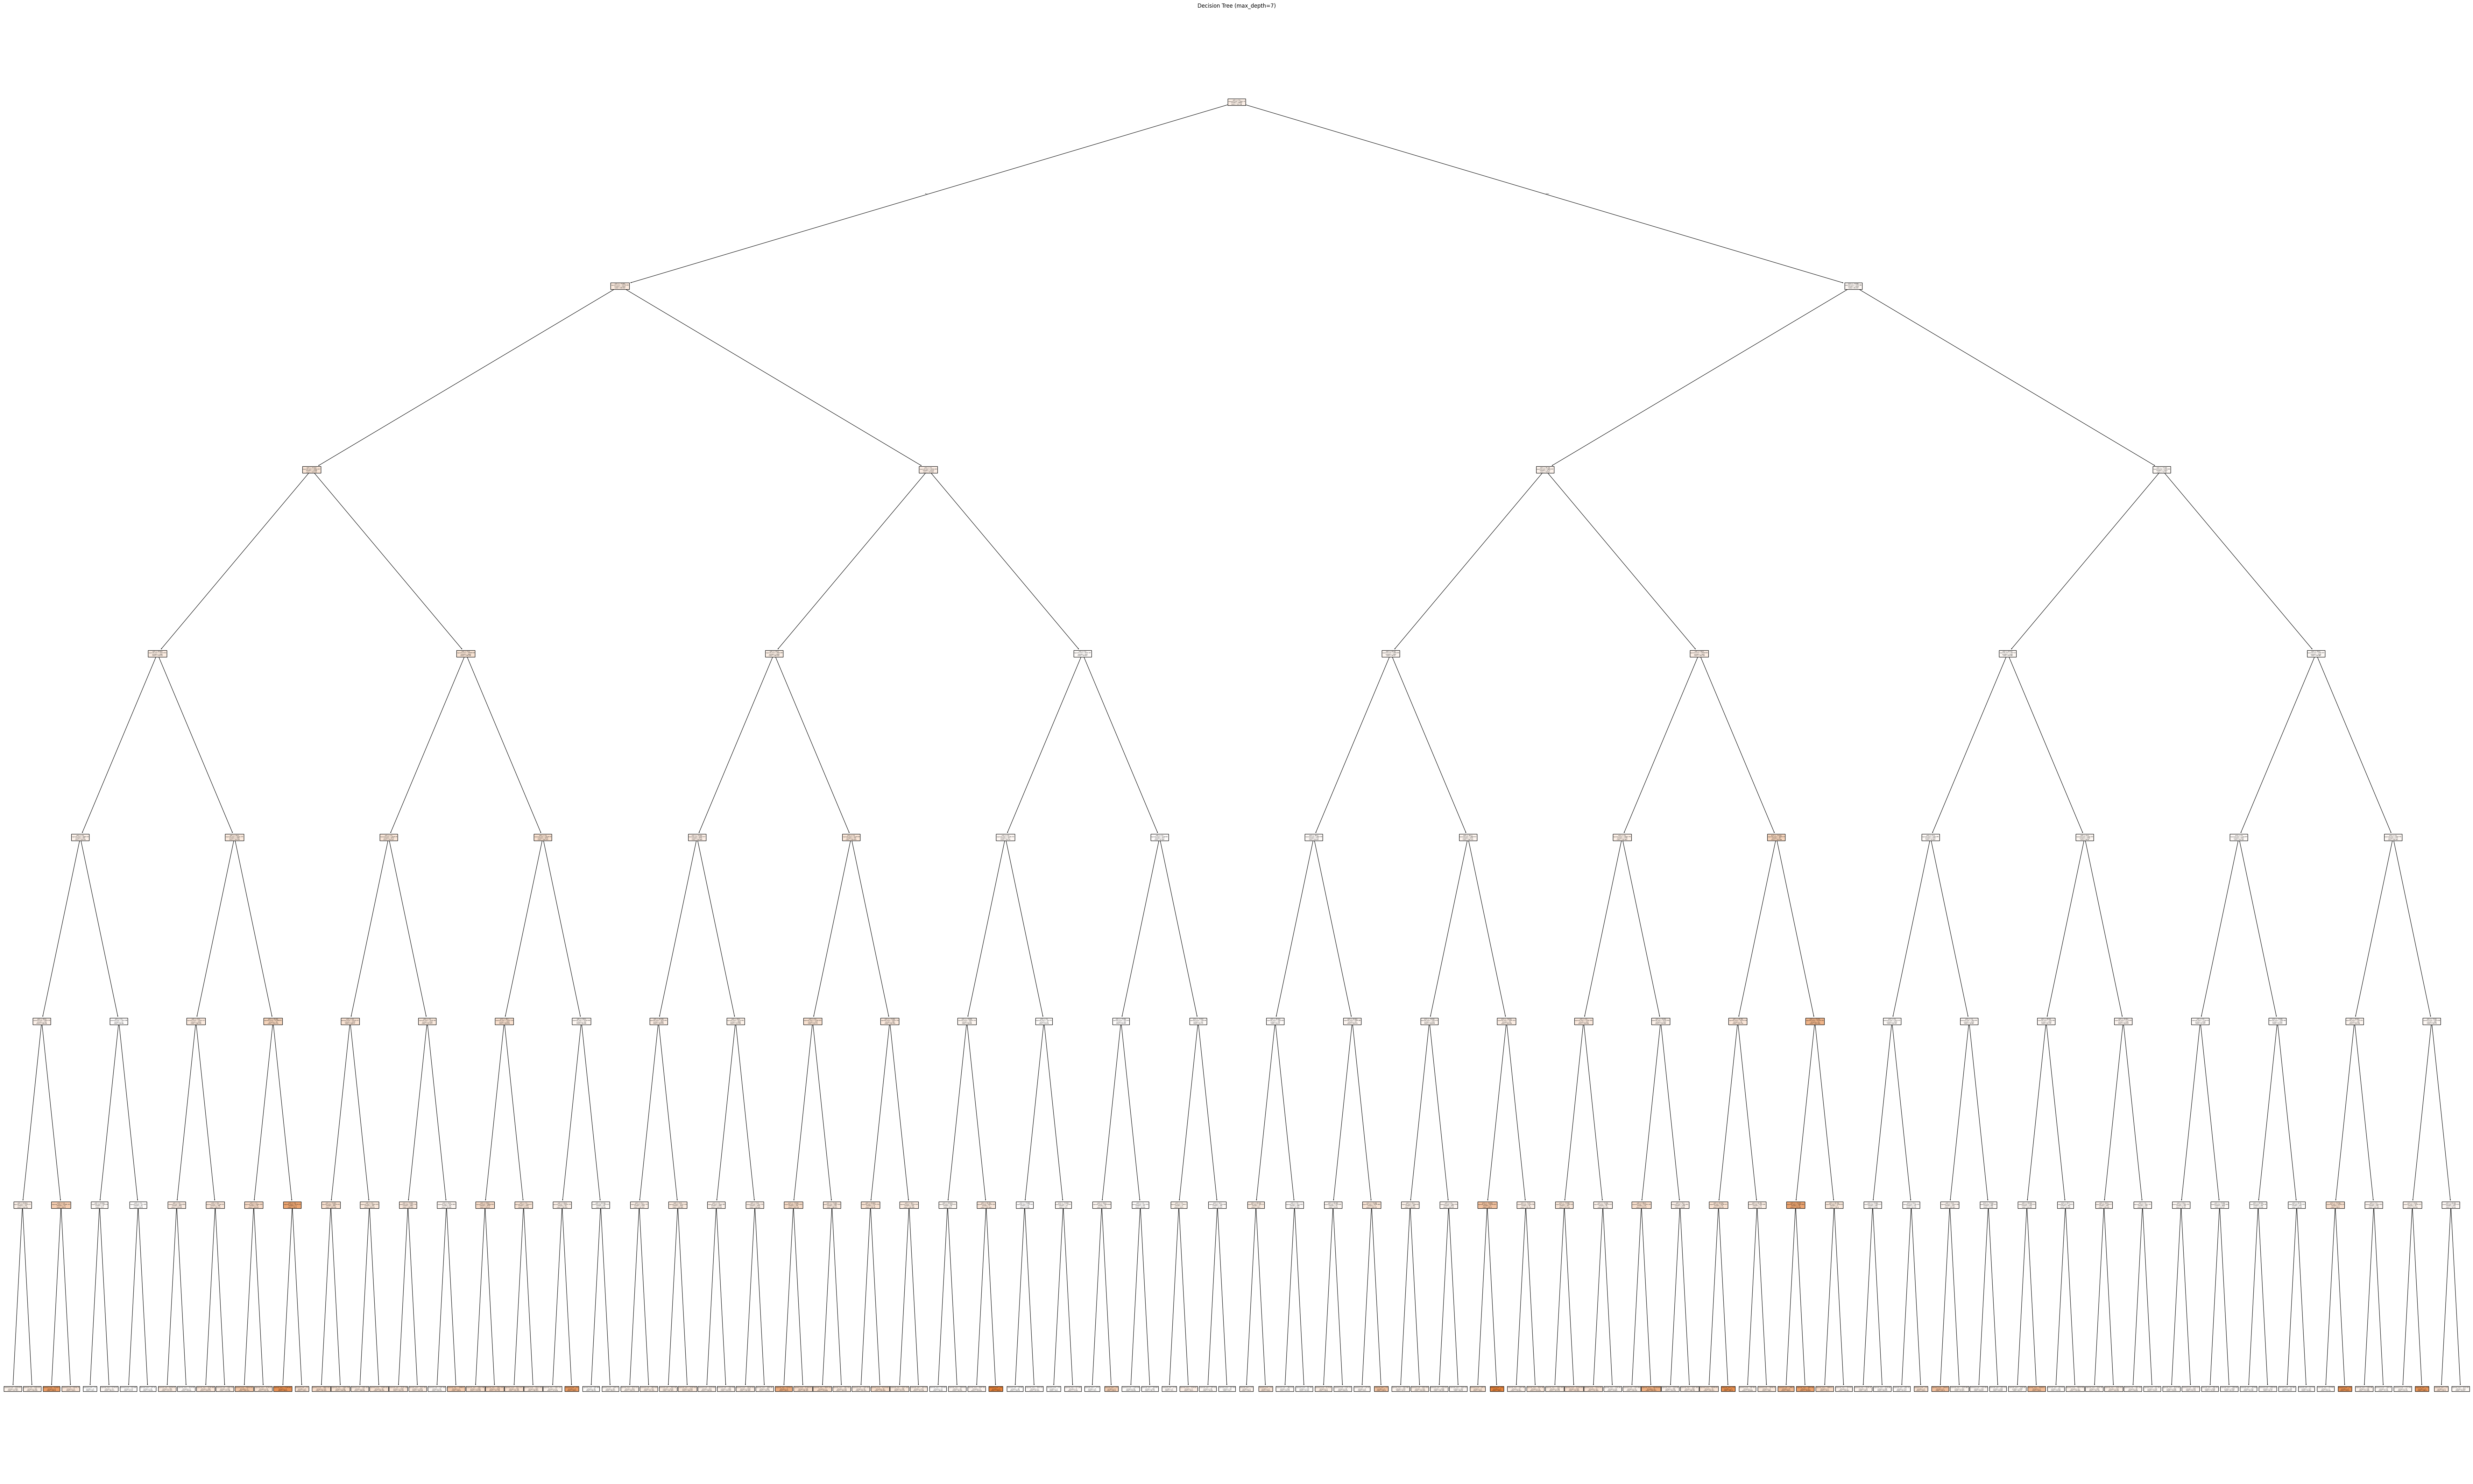

In [134]:
from sklearn.tree import plot_tree

plt.figure(figsize=(100,60))
plot_tree(tree3, filled=True)
plt.title("Decision Tree (max_depth=7)")
plt.show()

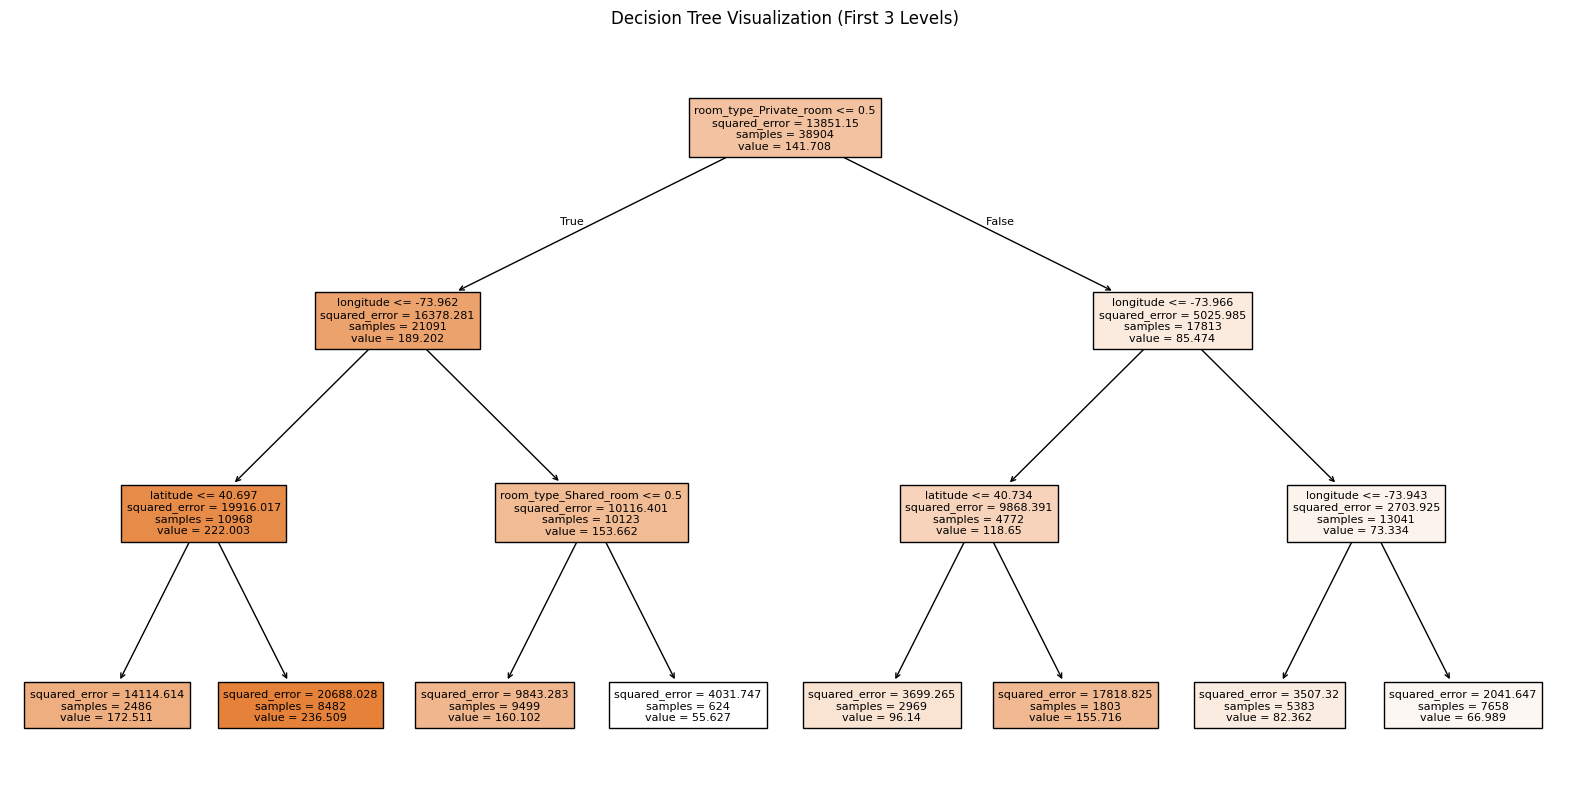

In [135]:
plt.figure(figsize=(20,10))
plot_tree(tree1,
          filled=True,
          feature_names=x.columns,
          max_depth=3,
          fontsize=8)

plt.title("Decision Tree Visualization (First 3 Levels)")
plt.show()